✅ Connected to warehouse
Loaded 134,057 events

📊 Cohort sizes:
cohort_month
2025-01    1313.0
2025-02     854.0
2025-03     780.0
2025-04     512.0
2025-05     436.0
2025-06     301.0
2025-07     238.0
2025-08     176.0
2025-09     132.0
2025-10     114.0
2025-11      86.0
2025-12      58.0
Freq: M, Name: 0, dtype: float64

📊 Number of cohorts: 12


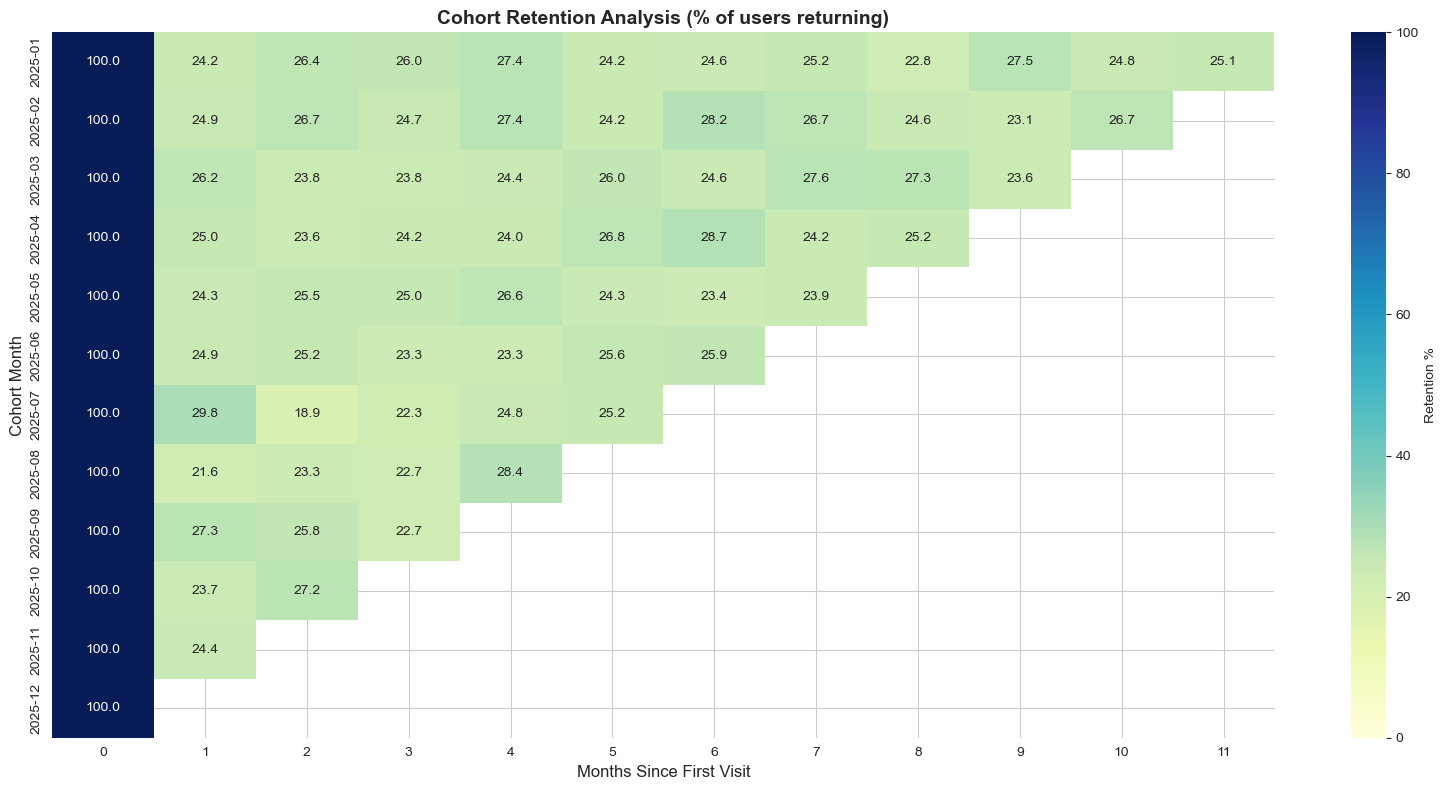

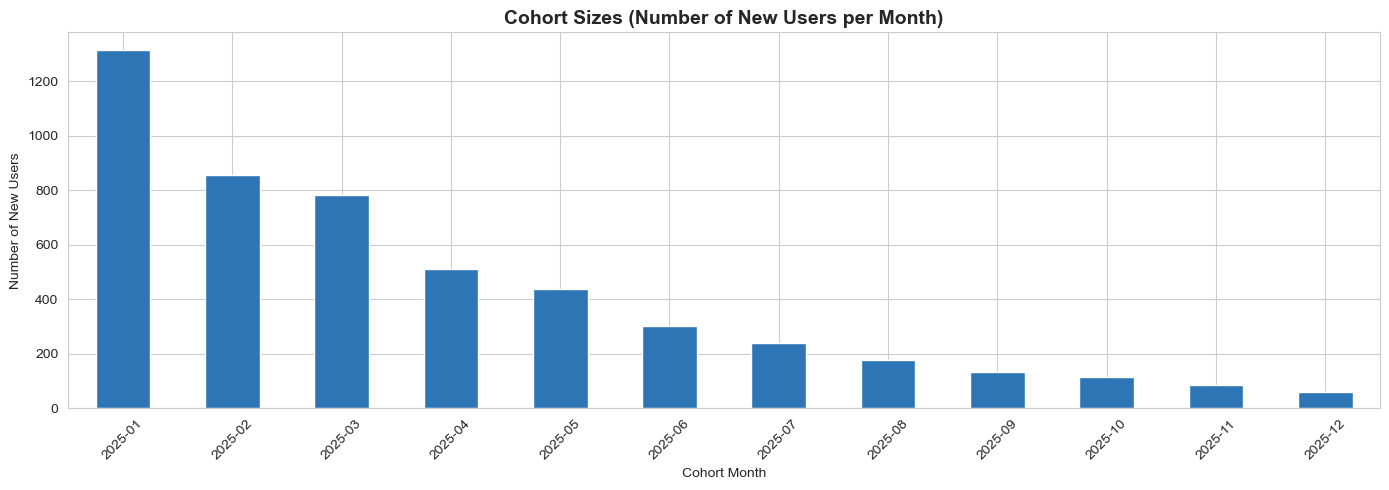

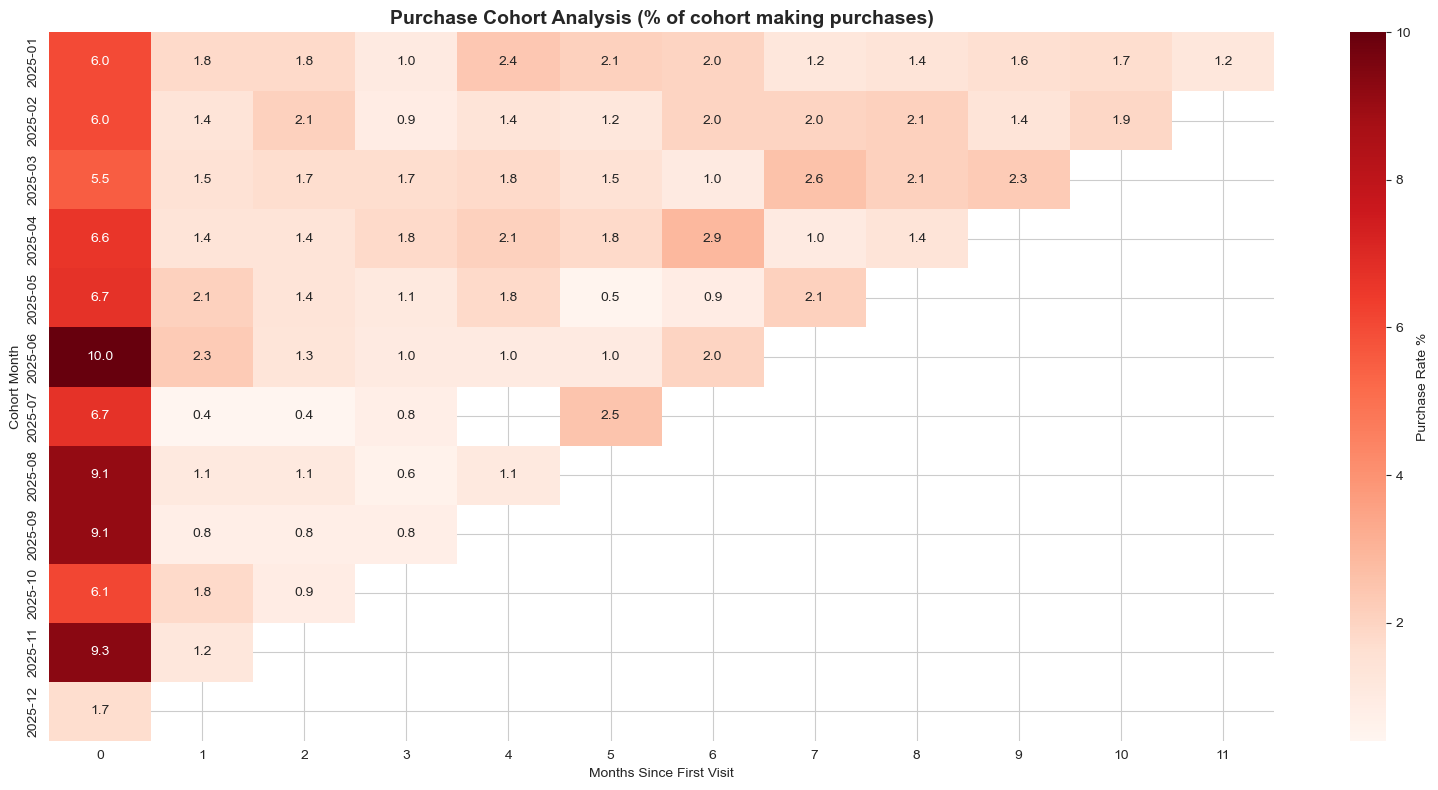


✅ Cohort SQL saved to sql/cohort/01_cohort_retention.sql
✅ Retention table saved to data/processed/cohort_retention.csv

🎉 Day 6 complete!


In [1]:
# Day 6: Cohort Retention Analysis
# =================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

load_dotenv('../.env')
engine = create_engine(os.getenv('DATABASE_URL'))
sns.set_style('whitegrid')
print("✅ Connected to warehouse")

# ===== QUERY 1: GET ALL EVENTS WITH COHORT =====
query = """
SELECT 
    user_id,
    timestamp,
    event_type
FROM fact_events
ORDER BY user_id, timestamp;
"""
df = pd.read_sql(query, engine)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"Loaded {len(df):,} events")

# ===== STEP 1: ASSIGN COHORT MONTH TO EACH USER =====
# Cohort = the month when a user FIRST appeared
df['event_month'] = df['timestamp'].dt.to_period('M')
cohort_month = df.groupby('user_id')['event_month'].min().reset_index()
cohort_month.columns = ['user_id', 'cohort_month']
df = df.merge(cohort_month, on='user_id')

# ===== STEP 2: CALCULATE COHORT INDEX (months since first visit) =====
df['cohort_index'] = (df['event_month'].dt.year - df['cohort_month'].dt.year) * 12 + \
                     (df['event_month'].dt.month - df['cohort_month'].dt.month)

# ===== STEP 3: BUILD COHORT TABLE (user counts) =====
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['user_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='user_id')

# ===== STEP 4: CALCULATE RETENTION PERCENTAGES =====
cohort_sizes = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print(f"\n📊 Cohort sizes:\n{cohort_sizes}")
print(f"\n📊 Number of cohorts: {len(cohort_pivot)}")

# ===== VISUALIZE: RETENTION HEATMAP =====
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(retention.round(1), 
            annot=True, 
            fmt='.1f', 
            cmap='YlGnBu',
            cbar_kws={'label': 'Retention %'},
            vmin=0, vmax=100,
            ax=ax)
ax.set_title('Cohort Retention Analysis (% of users returning)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Visit', fontsize=12)
ax.set_ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
plt.show()

# ===== VISUALIZE: COHORT SIZE BAR CHART =====
fig, ax = plt.subplots(figsize=(14, 5))
cohort_sizes.plot(kind='bar', color='#2E75B6', ax=ax)
ax.set_title('Cohort Sizes (Number of New Users per Month)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cohort Month')
ax.set_ylabel('Number of New Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== PURCHASER COHORTS =====
purchasers = df[df['event_type'] == 'purchase'][['user_id', 'event_month', 'cohort_month']]
purchase_cohort = purchasers.groupby(['cohort_month', 'event_month'])['user_id'].nunique().reset_index()
purchase_cohort['cohort_index'] = (purchase_cohort['event_month'].dt.year - purchase_cohort['cohort_month'].dt.year) * 12 + \
                                   (purchase_cohort['event_month'].dt.month - purchase_cohort['cohort_month'].dt.month)
purchase_pivot = purchase_cohort.pivot(index='cohort_month', columns='cohort_index', values='user_id')
purchase_retention = purchase_pivot.divide(cohort_sizes, axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(purchase_retention.round(1), 
            annot=True, 
            fmt='.1f', 
            cmap='Reds',
            cbar_kws={'label': 'Purchase Rate %'},
            ax=ax)
ax.set_title('Purchase Cohort Analysis (% of cohort making purchases)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Visit')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.show()

# ===== SAVE SQL =====
os.makedirs('../sql/cohort', exist_ok=True)

cohort_sql = """
-- Cohort Retention Analysis
WITH user_first_month AS (
    SELECT 
        user_id,
        DATE_TRUNC('month', MIN(timestamp)) AS cohort_month
    FROM fact_events
    GROUP BY user_id
),
user_activity AS (
    SELECT 
        f.user_id,
        u.cohort_month,
        DATE_TRUNC('month', f.timestamp) AS activity_month,
        EXTRACT(MONTH FROM AGE(DATE_TRUNC('month', f.timestamp), u.cohort_month)) AS months_since_first
    FROM fact_events f
    JOIN user_first_month u ON f.user_id = u.user_id
)
SELECT 
    cohort_month,
    months_since_first,
    COUNT(DISTINCT user_id) AS retained_users
FROM user_activity
GROUP BY cohort_month, months_since_first
ORDER BY cohort_month, months_since_first;
"""

with open('../sql/cohort/01_cohort_retention.sql', 'w') as f:
    f.write(cohort_sql)

# ===== SAVE RESULTS =====
retention.to_csv('../data/processed/cohort_retention.csv')
print("\n✅ Cohort SQL saved to sql/cohort/01_cohort_retention.sql")
print("✅ Retention table saved to data/processed/cohort_retention.csv")
print("\n🎉 Day 6 complete!")